### Agent 1: take in ps and subdivide into uselful topics that would have research papers

Model will divide ps into:  
- main_objective
- problem_type
- subproblems

Model will subdivide ps ka searchable query into:  
- title
- description
- why_it_matters
- search_queries

so the order is ps -> multiple sub-problems -> multiple searchable queries

##### imports and api keys

In [10]:
from typing import List
from typing_extensions import TypedDict, Annotated
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END

In [11]:
import arxiv

In [12]:
import os
from dotenv import load_dotenv
os.getcwd()

'c:\\Users\\fkrii\\OneDrive\\Desktop\\Langchain_Langgraph'

In [13]:
load_dotenv(r".env")

True

In [14]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

##### Creating the first agent - ps breakdown

In [43]:
class SubProblem(TypedDict): #for each individual subtopic the ps has been divided into
    title: Annotated[str, "Short name of the subproblem"]
    description: Annotated[str, "What this subproblem means technically"]
    why_it_matters: Annotated[str, "Why this subproblem is important for solving the problem statement"]
    search_queries: Annotated[List[str], "Academic/research search queries useful for finding papers"]


class ProblemDecomposition(TypedDict):  #for the ps
    main_objective: Annotated[str, "Main goal of the problem statement"]
    problem_type: Annotated[str, "Broad type of problem: NLP, CV, ML, RAG, robotics, optimization, etc."]
    subproblems: Annotated[List[SubProblem], "List of useful technical subproblems"]

In [44]:
class ResearchState(TypedDict):  #state that will finally carry all info thru the graph
    problem_statement: str
    decomposed_problem_statement: ProblemDecomposition | None

#this will get updated for each agent i create, like not the fields but the whole ResearchState class so i can keep track of wht has been added removed for each agent

In [45]:
model = init_chat_model("groq:qwen/qwen3-32b")
structured_model = model.with_structured_output(ProblemDecomposition)

In [46]:
system_prompt = """
You are an expert AI research assistant helping a team solve technical competition problem statements.
Your task is to decompose the given problem statement into useful technical subproblems that can each be researched on their own to give useful insights and later the ideas can be merged to solve the overall problem statement.

Rules:
1. Do not solve the problem directly.
2. Break it into subproblems that can be searched independently in research papers.
3. Each subproblem should be specific enough to generate useful academic search queries.
4. Prefer ML/AI/research-oriented decomposition.
5. Avoid vague items like "build model" unless you specify what kind of model/research area.
6. Search queries should be suitable for arXiv, Semantic Scholar, Papers with Code, or Google Scholar.
7. The output should be useful for a later paper retrieval agent.
"""

def decompose(problem_statement: str) -> ProblemDecomposition:    #this is not a node functionality, im defining node to breakdown the ps
    messages = [
        ("system", system_prompt),
        ("user", f"Problem Statement:\n{problem_statement}")
    ]

    return structured_model.invoke(messages)

In [47]:
#defining node functionality of the langgraph node
def decompose_problem_node(state: ResearchState):
    ps = state["problem_statement"]

    decomposition = decompose(ps)

    return {
        "decomposed_problem_statement": decomposition
    }

In [48]:
#building initial basic graph
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", END)

graph = graph_builder.compile()

In [49]:
#testing
test_ps = """
Build an AI system that takes competition problem statements, breaks them into technical components,
searches research papers for each component, ranks papers by usefulness, and generates an implementation plan.
"""

result = graph.invoke({
    "problem_statement": test_ps,
    "decomposed_problem_statement": None
})

In [50]:
#pretty print
decomp = result["decomposed_problem_statement"]

print("MAIN OBJECTIVE:")
print(decomp["main_objective"])

print("\nPROBLEM TYPE:")
print(decomp["problem_type"])

print("\nSUBPROBLEMS:")

for i, sp in enumerate(decomp["subproblems"], start=1):
    print(f"\n{i}. {sp['title']}")
    print("Description:", sp["description"])
    print("Why it matters:", sp["why_it_matters"])
    
    print("Search queries:")
    for q in sp["search_queries"]:
        print(" -", q)

MAIN OBJECTIVE:
Build an AI system that takes competition problem statements, breaks them into technical components, searches research papers for each component, ranks papers by usefulness, and generates an implementation plan.

PROBLEM TYPE:
NLP + Knowledge Management + Information Retrieval

SUBPROBLEMS:

1. Problem Statement Understanding
Description: Parsing and semantic comprehension of competition problem statements to identify technical requirements and constraints
Why it matters: Enables accurate identification of components that need research paper support
Search queries:
 - problem statement comprehension NLP
 - competition problem parsing techniques
 - semantic understanding of technical requirements

2. Technical Subproblem Decomposition
Description: Automatically decomposing problems into specific technical subcomponents that can be independently researched
Why it matters: Allows focused research paper searches for each component
Search queries:
 - task decomposition for A

##### Creating the second agent - taking in a query and giving all candidate papers to later be ranked

for now limitimg max possible papers selected per sub division of ps to 10

In [51]:
class PaperCandidate(TypedDict):  #this represents the record of one paper found by agent 2 to be sent for ranking
    title: str
    authors: List[str]
    published: str
    abstract: str
    url: str
    pdf_url: str
    source: str

class SearchTask(TypedDict):   #this represents one search job, both its fields are outputs of agent 1
    subproblem_title: str
    query: str

class PaperSearchResult(TypedDict):   #This represents the result of running one search query.
    subproblem_title: str
    query_used: str
    papers: List[PaperCandidate]

Workflow of the above 3 classes:  
Agent 1 output -> SubProblem -> SearchTask -> Agent 2 searches arXiv -> PaperCandidate -> PaperSearchResult

In [52]:
#updating the ResearchState class(this is the one thats carrying the data thru the graph)
class ResearchState(TypedDict):
    problem_statement: str
    decomposed_problem_statement: ProblemDecomposition | None
    search_tasks: List[SearchTask] | None
    paper_results: List[PaperSearchResult] | None

In [53]:
def prepare_search_tasks_node(state: ResearchState):   #search tasks node functionality
    decomposition = state["decomposed_problem_statement"]

    search_tasks = []

    for subproblem in decomposition["subproblems"]:
        subproblem_title = subproblem["title"]

        for query in subproblem["search_queries"]:
            search_tasks.append({
                "subproblem_title": subproblem_title,
                "query": query
            })

    return {
        "search_tasks": search_tasks
    }

In [61]:
def search_arxiv_papers(query: str, max_results: int = 10) -> List[PaperCandidate]:   #arxiv search func or tool basically
    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance
    )

    papers = []

    for result in client.results(search):
        paper = {
            "title": result.title,
            "authors": [author.name for author in result.authors],
            "published": result.published.date().isoformat() if result.published else "",
            "abstract": result.summary.replace("\n", " "),
            "url": result.entry_id,
            "pdf_url": result.pdf_url if result.pdf_url else "",
            "source": "arXiv"
        }

        papers.append(paper)

    return papers

In [62]:
def search_papers_node(state: ResearchState):   #paper search node
    search_tasks = state["search_tasks"]

    paper_results = []

    for task in search_tasks:
        subproblem_title = task["subproblem_title"]
        query = task["query"]

        papers = search_arxiv_papers(query, max_results=10)

        paper_results.append({
            "subproblem_title": subproblem_title,
            "query_used": query,
            "papers": papers
        })

    return {
        "paper_results": paper_results
    }

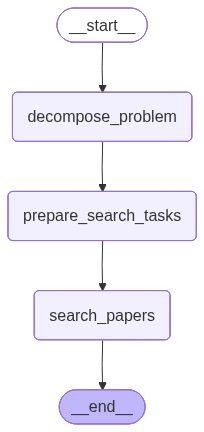

In [63]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("prepare_search_tasks", prepare_search_tasks_node)
graph_builder.add_node("search_papers", search_papers_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "prepare_search_tasks")
graph_builder.add_edge("prepare_search_tasks", "search_papers")
graph_builder.add_edge("search_papers", END)

graph = graph_builder.compile()
graph

##### Removing duplicate papers

In [64]:
class DeduplicatedPaperCandidate(TypedDict):
    title: str
    authors: List[str]
    published: str
    abstract: str
    url: str
    pdf_url: str
    source: str
    found_under_subproblems: List[str]
    found_by_queries: List[str]

In [65]:
#updating ResearchState
class ResearchState(TypedDict):
    problem_statement: str
    decomposed_problem_statement: ProblemDecomposition | None
    search_tasks: List[SearchTask] | None
    paper_results: List[PaperSearchResult] | None
    deduplicated_papers: List[DeduplicatedPaperCandidate] | None

In [66]:
def deduplicate_papers_node(state: ResearchState):    #node functionality
    paper_results = state["paper_results"]

    paper_map = {}

    for result_group in paper_results:
        subproblem_title = result_group["subproblem_title"]
        query_used = result_group["query_used"]

        for paper in result_group["papers"]:
            paper_id = paper["url"]  # unique key for arXiv papers

            if paper_id not in paper_map:
                paper_map[paper_id] = {
                    "title": paper["title"],
                    "authors": paper["authors"],
                    "published": paper["published"],
                    "abstract": paper["abstract"],
                    "url": paper["url"],
                    "pdf_url": paper["pdf_url"],
                    "source": paper["source"],
                    "found_under_subproblems": [subproblem_title],
                    "found_by_queries": [query_used]
                }

            else:
                if subproblem_title not in paper_map[paper_id]["found_under_subproblems"]:
                    paper_map[paper_id]["found_under_subproblems"].append(subproblem_title)

                if query_used not in paper_map[paper_id]["found_by_queries"]:
                    paper_map[paper_id]["found_by_queries"].append(query_used)

    deduplicated_papers = list(paper_map.values())

    return {
        "deduplicated_papers": deduplicated_papers
    }

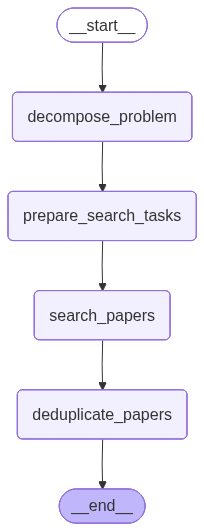

In [67]:
#rebuilding agent 2 with this deduplication
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("decompose_problem", decompose_problem_node)
graph_builder.add_node("prepare_search_tasks", prepare_search_tasks_node)
graph_builder.add_node("search_papers", search_papers_node)
graph_builder.add_node("deduplicate_papers", deduplicate_papers_node)

graph_builder.add_edge(START, "decompose_problem")
graph_builder.add_edge("decompose_problem", "prepare_search_tasks")
graph_builder.add_edge("prepare_search_tasks", "search_papers")
graph_builder.add_edge("search_papers", "deduplicate_papers")
graph_builder.add_edge("deduplicate_papers", END)

graph = graph_builder.compile()
graph

In [68]:
#testing
test_ps = """
Build an AI system that takes competition problem statements, breaks them into technical components,
searches research papers for each component, ranks papers by usefulness, and generates an implementation plan.
"""

result = graph.invoke({
    "problem_statement": test_ps,
    "decomposed_problem_statement": None,
    "search_tasks": None,
    "paper_results": None,
    "deduplicated_papers": None
})

In [69]:
#printing counts to see if max count is working
print("Number of search tasks:", len(result["search_tasks"]))

total_raw_papers = sum(
    len(group["papers"]) for group in result["paper_results"]
)

print("Total raw paper hits:", total_raw_papers)
print("Unique papers after deduplication:", len(result["deduplicated_papers"]))

Number of search tasks: 15
Total raw paper hits: 150
Unique papers after deduplication: 139
